# Fitting-Based IPA Analysis — SLP MNIST

This notebook computes **Information Processing Accuracy (IPA)** for the SLP MNIST pruning experiments using a per-run curve-fitting approach.

### What it does

Instead of fitting the averaged CE curve, each individual run's `CE_TEST` trajectory is fitted with the decay model:

$$CE(x) = A + \frac{B}{(x+1)^n}$$

For each run, the asymptote `CEasy = A` is extracted directly from the fit. The learning threshold `CE_l` and batch-number-to-learn `BN_learn` are then derived per run, and the results are averaged across all valid runs:

$$\text{IPA} = \frac{|\langle CE_l \rangle - \ln(10)|}{\langle BN_{learn} \rangle}$$

### Workflow (run cells in order)

| Cell | Purpose |
|------|---------|
| **1** | Config, imports, fitting functions |
| **2** | Per-run fitting → averaged CSVs |
| **3** | Plot averaged raw CE + reconstructed mean fit |
| **4** | Print IPA verification table |
| **5** | Write `Fitting_IPA_output.txt` + IPA line plot + BNL/CEL bar plots |

### Datasets covered
- Pruning layers: `ALL`
- Pruning percentages: 0% – 100% (step 10%)
- Batch sizes: 64, 1024, 60000


## Cell 1 — Configuration, Imports & Fitting Functions

Sets all global config (paths, batch sizes, pruning levels), creates output directories, defines the color palette and matplotlib style, and declares the four fitting functions used throughout:

- `initialize_guesses(x, y)` — estimates starting values for A, B, n from data percentiles; guards against division by zero when the curve is already flat.
- `model(params, x)` — evaluates `A + B / ((x+1)^n)`.
- `residual(params, x, data)` — weighted residual (weight = x²) passed to `lmfit.minimize`.
- `fit_curve(x, y)` — wraps the full fit pipeline; returns the `lmfit` result object or `None` on failure.

**Run this cell first** before any other cell.


In [2]:
"""
Fitting-based IPA for SLP-MNIST
================================
Instead of fitting the averaged CEave curve, this notebook fits each
individual CE_TEST run curve (up to 100 runs) using the model:

    CE(x) = A + B / ((x + 1)^n)

For each run:
  - CEasy  = A  (asymptotic CE from the fit)
  - CE_l   = ln(10) - 0.9 * (ln(10) - CEasy)
  - BN_learn = first batch number where CE_TEST <= CE_l

Then, across all valid runs for each (p, bs):
  - <CEasy>    = mean of fitted A values
  - <B>        = mean of fitted B values
  - <n>        = mean of fitted n values
  - <CE_l>     = mean of CE_l values
  - <BN_learn> = mean of BN_learn values
  - IPA        = |<CE_l> - ln(10)| / <BN_learn>

Outputs
-------
  Fitting_IPA_data/
      fitting_IPA_summary_bs_{bs}.csv   -- averaged results per (p, bs)
      fitting_IPA_summary_ALL.csv        -- combined across all batch sizes
      per_run/
          fitting_per_run_p_{p}_bs_{bs}.csv  -- per-run CEasy / B / n / CE_l / BN_learn
      Fitting_IPA_output.txt             -- IPA summary text (mirrors IPA_avg_std.txt)
  Fitting_IPA_graphs/
      CE_Test_Fit_Avg_BS_{bs}.png        -- averaged raw (faint) + reconstructed mean fit (bold)
      IPA_vs_Pruning_BS_{bs}.png
      BNL_vs_Pruning_BS_{bs}.png
      CEL_vs_Pruning_BS_{bs}.png
"""

import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from lmfit import minimize, Parameters

# =========================
# CONFIG (SLP-MNIST)
# =========================
BASE_DIR_ROOT = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST"
BASE_DIR      = os.path.join(BASE_DIR_ROOT, "prune_layers_ALL")

BATCH_DIR_TEMPLATE = "p-percentage_{:.1f}\\batch_size_{}"
FILE_PATTERN       = "slp_{:.1f}_{}_run_*.txt"

BATCH_SIZES    = [64, 1024, 60000]
PRUNING_LEVELS = [round(x * 0.1, 1) for x in range(11)]

LN10 = np.log(10)

# =========================
# OUTPUT DIRECTORIES
# =========================
FITTING_DATA_DIR  = os.path.join(BASE_DIR_ROOT, "Fitting_IPA_data")
FITTING_GRAPH_DIR = os.path.join(BASE_DIR_ROOT, "Fitting_IPA_graphs")
PER_RUN_DIR       = os.path.join(FITTING_DATA_DIR, "per_run")

os.makedirs(FITTING_DATA_DIR,  exist_ok=True)
os.makedirs(FITTING_GRAPH_DIR, exist_ok=True)
os.makedirs(PER_RUN_DIR,       exist_ok=True)

print(f"[INFO] Data   -> {FITTING_DATA_DIR}")
print(f"[INFO] Graphs -> {FITTING_GRAPH_DIR}")

# =========================
# COLOR LIST (matches avg / AUC notebooks)
# =========================
COLOR_LIST = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#800080",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#B9D9EB", "#17becf"
][::-1]

# =========================
# STYLE
# =========================
plt.rcParams.update({
    "font.size":       18,
    "axes.titlesize":  18,
    "axes.labelsize":  18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15
})

# =========================
# FIT PARAMETERS
# =========================
A_MIN, A_MAX = 0.1, 2.3
B_MIN, B_MAX = 0, 1000
N_MIN, N_MAX = 0.5, 3.0

# =========================
# FITTING FUNCTIONS  (identical to fitting_function.ipynb in SLP-FMNIST)
# =========================
def initialize_guesses(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]

    A0 = np.percentile(y, 5)
    B0 = np.percentile(y, 95) - A0
    n0 = 0.5

    if len(x) > 10:
        denom = y[0] - A0
        if abs(denom) > 1e-10:
            frac = max(1e-6, (y[0] - y[-1]) / denom)
            if frac > 0:
                n0 = max(0.3, min(1.5, -np.log(frac)))

    return A0, n0, B0


def model(params, x):
    vals = params.valuesdict()
    A, B, n = vals['A'], vals['B'], vals['n']
    return A + B / ((x + 1)**n)


def residual(params, x, data):
    weight = x
    return weight * (model(params, x) - data)


def fit_curve(x, y):
    mask  = ~np.isnan(y)
    x_fit = x[mask]
    y_fit = y[mask]

    if len(x_fit) < 10:
        return None

    A0, n0, B0 = initialize_guesses(x_fit, y_fit)

    params = Parameters()
    params.add('A', value=A0, min=A_MIN, max=A_MAX)
    params.add('B', value=B0, min=B_MIN, max=B_MAX)
    params.add('n', value=n0, min=N_MIN, max=N_MAX)

    try:
        return minimize(residual, params, args=(x_fit, y_fit))
    except Exception:
        return None


[INFO] Data   -> C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\Fitting_IPA_data
[INFO] Graphs -> C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\Fitting_IPA_graphs


## Cell 2 — Per-Run Fitting & Averaging

For each combination of pruning percentage and batch size, this cell iterates over all ~100 run `.txt` files. Each run's `CE_TEST` vs `Batch_Number` curve is fitted independently using the model `CE(x) = A + B / ((x+1)^n)`. From each successful fit:

- `CEasy = A` — the asymptotic CE value
- `CE_l = ln(10) - 0.9 * (ln(10) - CEasy)` — the learning threshold (90% of the way from ln(10) to the asymptote)
- `BN_learn` — the first batch number where `CE_TEST ≤ CE_l`

Runs where the fit fails or `BN_learn` is never reached are excluded. The valid runs are averaged to give `<CEasy>`, `<B>`, `<n>`, `<CE_l>`, `<BN_learn>`, and `IPA = |<CE_l> - ln(10)| / <BN_learn>`.

**Outputs:**
- `Fitting_IPA_data/per_run/fitting_per_run_p_{p}_bs_{bs}.csv` — one row per valid run
- `Fitting_IPA_data/fitting_IPA_summary_bs_{bs}.csv` — averaged results including `Avg_B`, `Avg_n` (needed by Cell 3)
- `Fitting_IPA_data/fitting_IPA_summary_ALL.csv` — all batch sizes combined


In [4]:
# =========================
# CELL 2 — Per-run fitting + averaging (save CSVs)
# =========================
# For each (p, bs): fit each run's CE_TEST curve, extract CEasy/B/n/CE_l/BN_learn,
# average across valid runs, and save per-run + summary CSVs.
# Summary CSVs include avg_B and avg_n so Cell 3 can reconstruct mean fit curves.
# =========================

all_summary_rows = []

for bs in BATCH_SIZES:

    print(f"\n{'='*40}")
    print(f"  Batch Size: {bs}")
    print(f"{'='*40}")

    summary_rows = []

    for p in PRUNING_LEVELS:

        folder = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(p, bs))
        files  = sorted(glob.glob(os.path.join(folder, FILE_PATTERN.format(p, bs))))

        if not files:
            print(f"  [WARNING] No files for p={p}, bs={bs}")
            continue

        ceasy_list = []
        B_list     = []
        n_list     = []
        cel_list   = []
        bnl_list   = []
        per_run_rows = []

        for f in files:
            try:
                df = pd.read_csv(f, sep=r"\s+")
                df.columns = df.columns.str.strip()
                df["CE_TEST"]      = pd.to_numeric(df["CE_TEST"],      errors="coerce")
                df["Batch_Number"] = pd.to_numeric(df["Batch_Number"], errors="coerce")
                df = df.dropna(subset=["CE_TEST", "Batch_Number"])
            except Exception as e:
                print(f"  [ERROR] Reading {os.path.basename(f)}: {e}")
                continue

            x = df["Batch_Number"].to_numpy(dtype=float)
            y = df["CE_TEST"].to_numpy(dtype=float)

            if len(x) < 10:
                continue

            # ---- Fit individual CE_TEST curve ----
            fit = fit_curve(x, y)
            if fit is None:
                continue

            ceasy = fit.params['A'].value
            B_val = fit.params['B'].value
            n_val = fit.params['n'].value
            ce_l  = LN10 - 0.9 * (LN10 - ceasy)

            # ---- Find BN_learn: first batch where CE_TEST <= CE_l ----
            bn_learn = None
            for i in range(len(y)):
                if y[i] <= ce_l:
                    bn_learn = x[i]
                    break

            if bn_learn is None:
                continue

            ceasy_list.append(ceasy)
            B_list.append(B_val)
            n_list.append(n_val)
            cel_list.append(ce_l)
            bnl_list.append(bn_learn)

            per_run_rows.append({
                "file":     os.path.basename(f),
                "CEasy":    ceasy,
                "B":        B_val,
                "n":        n_val,
                "CE_l":     ce_l,
                "BN_learn": bn_learn
            })

        n_valid = len(cel_list)
        print(f"  p={int(p*100):3d}%: {n_valid}/{len(files)} runs valid")

        if n_valid == 0:
            continue

        # ---- Average across runs ----
        avg_ceasy = np.mean(ceasy_list)
        avg_B     = np.mean(B_list)
        avg_n     = np.mean(n_list)
        avg_cel   = np.mean(cel_list)
        avg_bnl   = np.mean(bnl_list)
        std_cel   = np.std(cel_list,  ddof=1) if n_valid > 1 else 0.0
        std_bnl   = np.std(bnl_list,  ddof=1) if n_valid > 1 else 0.0

        # ---- IPA = |<CE_l> - ln(10)| / <BN_learn> ----
        ipa = abs(avg_cel - LN10) / avg_bnl

        row = {
            "Pruning_Percentage": p,
            "Batch_Size":         bs,
            "N_valid_runs":       n_valid,
            "Avg_CEasy":          avg_ceasy,
            "Avg_B":              avg_B,
            "Avg_n":              avg_n,
            "Avg_CE_l":           avg_cel,
            "Std_CE_l":           std_cel,
            "Avg_BN_learn":       avg_bnl,
            "Std_BN_learn":       std_bnl,
            "IPA":                ipa
        }
        summary_rows.append(row)
        all_summary_rows.append(row)

        # ---- Save per-run CSV ----
        if per_run_rows:
            per_run_df   = pd.DataFrame(per_run_rows)
            per_run_path = os.path.join(PER_RUN_DIR, f"fitting_per_run_p_{p}_bs_{bs}.csv")
            per_run_df.to_csv(per_run_path, index=False)

    # ---- Save per-BS summary CSV ----
    if summary_rows:
        summary_df   = pd.DataFrame(summary_rows)
        summary_path = os.path.join(FITTING_DATA_DIR, f"fitting_IPA_summary_bs_{bs}.csv")
        summary_df.to_csv(summary_path, index=False)
        print(f"\n  [SAVED] {summary_path}")

# ---- Save combined summary CSV ----
if all_summary_rows:
    all_df   = pd.DataFrame(all_summary_rows)
    all_path = os.path.join(FITTING_DATA_DIR, "fitting_IPA_summary_ALL.csv")
    all_df.to_csv(all_path, index=False)
    print(f"\n[SAVED] Combined summary: {all_path}")

print("\n[DONE] Per-run fitting and IPA computation complete.")



  Batch Size: 64
  p=  0%: 100/100 runs valid
  p= 10%: 100/100 runs valid
  p= 20%: 100/100 runs valid
  p= 30%: 100/100 runs valid
  p= 40%: 100/100 runs valid
  p= 50%: 100/100 runs valid
  p= 60%: 100/100 runs valid
  p= 70%: 100/100 runs valid
  p= 80%: 89/100 runs valid
  p= 90%: 0/100 runs valid
  p=100%: 0/100 runs valid

  [SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\Fitting_IPA_data\fitting_IPA_summary_bs_64.csv

  Batch Size: 1024
  p=  0%: 100/100 runs valid
  p= 10%: 100/100 runs valid
  p= 20%: 100/100 runs valid
  p= 30%: 100/100 runs valid
  p= 40%: 100/100 runs valid
  p= 50%: 100/100 runs valid
  p= 60%: 100/100 runs valid
  p= 70%: 100/100 runs valid
  p= 80%: 100/100 runs valid
  p= 90%: 8/100 runs valid
  p=100%: 0/100 runs valid

  [SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\Fitting_IPA_data\fitting_IPA_summary_bs_1024.csv

  Batch Size: 60000
  p=  0%: 100/100 runs valid
  p= 10%: 100/100 runs valid
  p= 20%: 

## Cell 3 — Fitted Curve Plots

For each batch size, produces one figure overlaying all 11 pruning percentages. Each pruning level is shown in two layers of the same color:

- **Faint line** (`alpha=0.3`): averaged raw `CE_TEST` data — loaded from `averaged_runs_p_{p}_bs_{bs}.csv` if it exists, otherwise computed on-the-fly by averaging all individual run `.txt` files.
- **Bold line**: the reconstructed mean fit curve `y = <CEasy> + <B> / ((x+1)^<n>)` using the per-P% averages stored in the summary CSV from Cell 2.

The plot uses the same style as `fitting_function.ipynb` (SLP-FMNIST): y-axis 0–2.5, ln(10) minor tick marker, legend upper right.

**Output:** `Fitting_IPA_graphs/CE_Test_Fit_Avg_BS_{bs}.png`


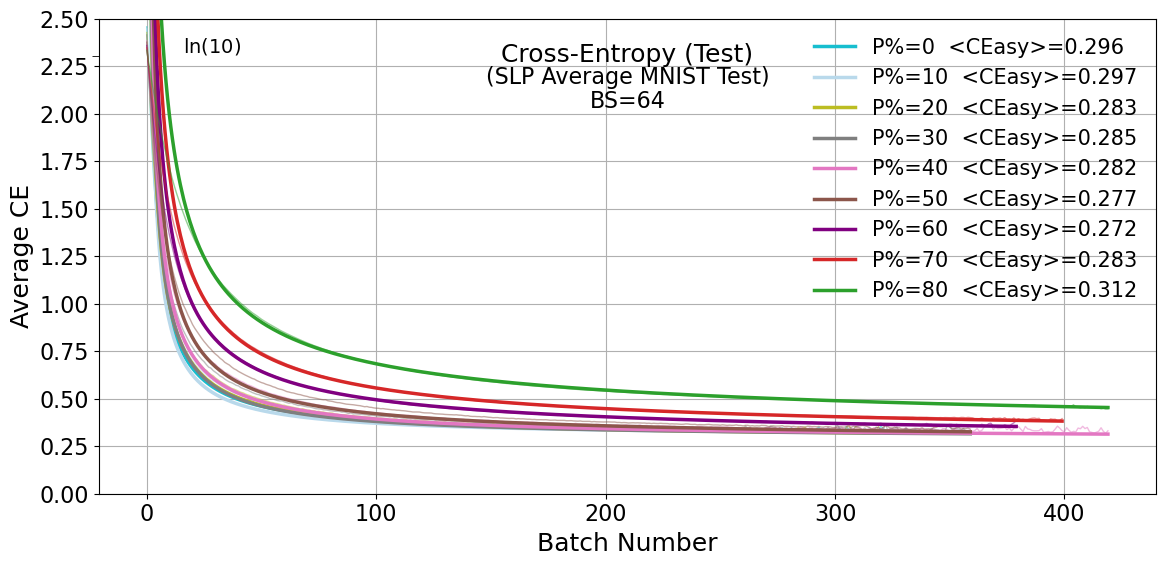

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\Fitting_IPA_graphs\CE_Test_Fit_Avg_BS_64.png


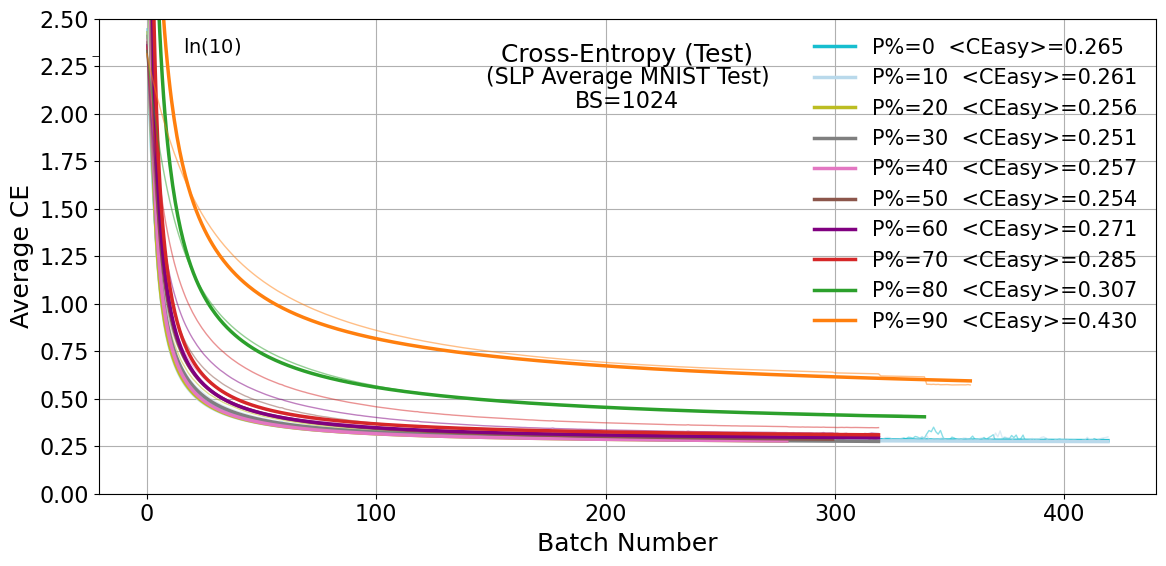

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\Fitting_IPA_graphs\CE_Test_Fit_Avg_BS_1024.png


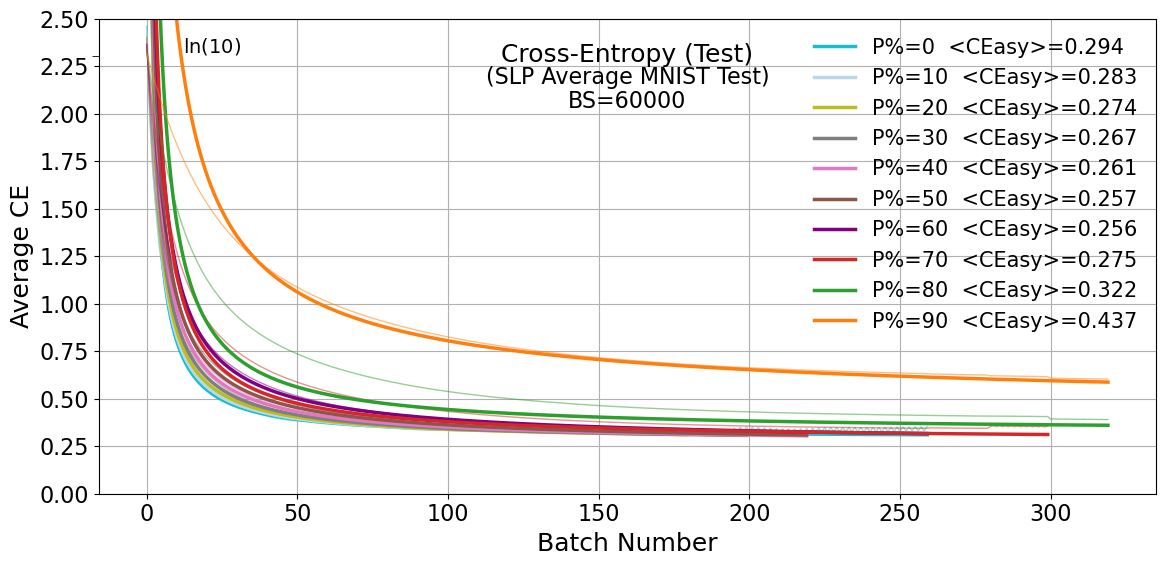

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\Fitting_IPA_graphs\CE_Test_Fit_Avg_BS_60000.png

[DONE] Fitted curve plots complete.


In [5]:
# =========================
# CELL 3 — Plot fitted curves (averaged raw + reconstructed mean fit)
# =========================
# For each batch size, one figure showing all pruning percentages overlaid:
#   - Faint line (alpha=0.3): averaged raw CE_TEST data
#   - Bold line: reconstructed mean fit  y = avg_CEasy + avg_B / ((x+1)^avg_n)
# Averaged raw data is loaded from averaged_runs_p_{p}_bs_{bs}.csv if it exists;
# otherwise it is computed on-the-fly from the individual run .txt files.
# Style matches fitting_function.ipynb (SLP-FMNIST).
# =========================

def _load_or_compute_avg(p, bs):
    """Return (x_avg, y_avg) arrays for averaged CE_TEST, or (None, None) on failure."""
    folder     = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(p, bs))
    avg_path   = os.path.join(folder, f"averaged_runs_p_{p:.1f}_bs_{bs}.csv")

    # ---- Try pre-computed averaged CSV first ----
    if os.path.isfile(avg_path):
        try:
            df_avg = pd.read_csv(avg_path)
            # Detect CE_Test column (could be Avg_CE_Test, CE_TEST, CE_Test, etc.)
            ce_col = next(
                (c for c in df_avg.columns if "CE" in c.upper() and "TEST" in c.upper()),
                None
            )
            bn_col = next(
                (c for c in df_avg.columns if "Batch" in c and "Number" in c),
                None
            )
            if ce_col and bn_col:
                x = df_avg[bn_col].to_numpy(dtype=float)
                y = df_avg[ce_col].to_numpy(dtype=float)
                mask = np.isfinite(x) & np.isfinite(y)
                return x[mask], y[mask]
        except Exception:
            pass

    # ---- Fall back: average from individual run files ----
    files = sorted(glob.glob(os.path.join(folder, FILE_PATTERN.format(p, bs))))
    if not files:
        return None, None

    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f, sep=r"\s+")
            df.columns = df.columns.str.strip()
            df["CE_TEST"]      = pd.to_numeric(df["CE_TEST"],      errors="coerce")
            df["Batch_Number"] = pd.to_numeric(df["Batch_Number"], errors="coerce")
            dfs.append(df[["Batch_Number", "CE_TEST"]].dropna())
        except Exception:
            continue

    if not dfs:
        return None, None

    combined = pd.concat(dfs, ignore_index=True)
    avg_df   = combined.groupby("Batch_Number", as_index=False)["CE_TEST"].mean()
    return avg_df["Batch_Number"].to_numpy(dtype=float), avg_df["CE_TEST"].to_numpy(dtype=float)


for bs in BATCH_SIZES:

    summary_path = os.path.join(FITTING_DATA_DIR, f"fitting_IPA_summary_bs_{bs}.csv")
    if not os.path.isfile(summary_path):
        print(f"[WARNING] No summary for BS={bs} — run Cell 2 first")
        continue

    summary_df = pd.read_csv(summary_path).sort_values("Pruning_Percentage").reset_index(drop=True)

    plt.figure(figsize=(12, 6))

    for i, row in summary_df.iterrows():
        p         = row["Pruning_Percentage"]
        avg_ceasy = row["Avg_CEasy"]
        avg_B     = row["Avg_B"]
        avg_n     = row["Avg_n"]
        color     = COLOR_LIST[i % len(COLOR_LIST)]

        # ---- Averaged raw data (faint) ----
        x_raw, y_raw = _load_or_compute_avg(p, bs)
        if x_raw is not None:
            plt.plot(x_raw, y_raw, color=color, alpha=0.5, linewidth=1)
            x_max = x_raw.max()
        else:
            x_max = row["Avg_BN_learn"] * 2.0

        # ---- Reconstructed mean fit (bold) ----
        x_fit = np.linspace(0, x_max, 600)
        y_fit = avg_ceasy + avg_B / ((x_fit + 1) ** avg_n)
        plt.plot(
            x_fit, y_fit,
            color=color, linewidth=2.5,
            label=f"P%={int(p*100)}  <CEasy>={avg_ceasy:.3f}"
        )

    plt.xlabel("Batch Number")
    plt.ylabel("Average CE")
    plt.ylim(0, 2.5)
    plt.yticks([x * 0.25 for x in range(0, 11)])

    plt.gca().yaxis.set_minor_locator(plt.FixedLocator([LN10]))
    plt.tick_params(axis='y', which='minor', length=5)
    plt.text(0.08, LN10 + 0.05, r"$\ln(10)$",
             transform=plt.gca().get_yaxis_transform(),
             fontsize=14, va="center", ha="left")

    plt.text(0.50, 0.95, "Cross-Entropy (Test)",
             transform=plt.gca().transAxes, va="top", ha="center")
    plt.text(0.50, 0.90, "(SLP Average MNIST Test)",
             transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)
    plt.text(0.50, 0.85, f"BS={bs}",
             transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)

    plt.legend(frameon=False, loc="upper right")
    plt.grid(True)
    plt.tight_layout()

    save_path = os.path.join(FITTING_GRAPH_DIR, f"CE_Test_Fit_Avg_BS_{bs}.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"[SAVED] {save_path}")

print("\n[DONE] Fitted curve plots complete.")


## Cell 4 — IPA Verification Table

Loads the per-BS summary CSVs written by Cell 2 and prints a formatted table of results. Columns: `P%`, `BS`, `IPA`, `<BN_learn>`, `<CE_l>`, `N_runs`. This is a read-only verification step — no files are written.


In [7]:
# =========================
# CELL 4 — Calculate IPA (verification table)
# =========================
# Loads fitting_IPA_summary_bs_{bs}.csv for each batch size and prints a
# clean table of IPA, <BN_learn>, and <CE_l> per (P%, BS).
# IPA = |<CE_l> - ln(10)| / <BN_learn>  (already stored in summary CSV from Cell 2)
# =========================

print(f"\n{'='*72}")
print(f"{'P%':>5}  {'BS':>8}  {'IPA':>14}  {'<BN_learn>':>12}  {'<CE_l>':>10}  {'N_runs':>8}")
print(f"{'='*72}")

for bs in BATCH_SIZES:
    summary_path = os.path.join(FITTING_DATA_DIR, f"fitting_IPA_summary_bs_{bs}.csv")
    if not os.path.isfile(summary_path):
        print(f"[WARNING] Missing summary for BS={bs} — run Cell 2 first")
        continue
    df_ipa = pd.read_csv(summary_path).sort_values("Pruning_Percentage")
    print(f"\n  --- BS = {bs} ---")
    for _, row in df_ipa.iterrows():
        p_pct = int(round(row["Pruning_Percentage"] * 100))
        print(
            f"{p_pct:>5}%  {int(row['Batch_Size']):>8}  "
            f"{row['IPA']:>14.8f}  {row['Avg_BN_learn']:>12.1f}  "
            f"{row['Avg_CE_l']:>10.6f}  {int(row['N_valid_runs']):>8}"
        )

print(f"\n{'='*72}")



   P%        BS             IPA    <BN_learn>      <CE_l>    N_runs

  --- BS = 64 ---
    0%        64      0.04642718          38.6    0.508639       100
   10%        64      0.04344248          41.3    0.510148       100
   20%        64      0.03708259          48.6    0.498888       100
   30%        64      0.03407787          52.8    0.504637       100
   40%        64      0.03007215          59.7    0.507578       100
   50%        64      0.02500231          71.8    0.506919       100
   60%        64      0.02029599          87.9    0.518161       100
   70%        64      0.01590149         110.8    0.540223       100
   80%        64      0.01088963         157.4    0.588665       100
   90%        64      0.00559062         280.2    0.736320        69

  --- BS = 1024 ---
    0%      1024      0.06186760          29.5    0.478110       100
   10%      1024      0.05850984          31.1    0.480003       100
   20%      1024      0.05229057          35.0    0.475030     

## Cell 5 — IPA Output File & Plots

Writes `Fitting_IPA_data/Fitting_IPA_output.txt` — a plain-text summary table mirroring the `IPA_avg_std.txt` format from `IPA_Analysis_part_I.py`, with one row per (P%, BS).

Then produces three figures per batch size saved to `Fitting_IPA_graphs/`:

| Plot | Type | File |
|------|------|------|
| IPA vs Pruning% | **Line plot** with circle markers | `IPA_vs_Pruning_BS_{bs}.png` |
| `<BN_learn>` vs Pruning% | Bar chart with std error bars | `BNL_vs_Pruning_BS_{bs}.png` |
| `<CE_l>` vs Pruning% | Bar chart with std error bars + ln(10) reference | `CEL_vs_Pruning_BS_{bs}.png` |


In [ ]:
# =========================
# CELL 5 — IPA output file + plots
# =========================

# ---- Write output text file ----
output_txt_path = os.path.join(FITTING_DATA_DIR, "Fitting_IPA_output.txt")
with open(output_txt_path, "w") as fout:
    header = f"{'P%':>5}  {'BS':>8}  {'IPA':>14}  {'<BN_learn>':>12}  {'<CE_l>':>10}  {'N_valid_runs':>13}\n"
    fout.write(header)
    fout.write("-" * len(header.rstrip()) + "\n")
    for bs in BATCH_SIZES:
        summary_path = os.path.join(FITTING_DATA_DIR, f"fitting_IPA_summary_bs_{bs}.csv")
        if not os.path.isfile(summary_path):
            continue
        df_out = pd.read_csv(summary_path).sort_values("Pruning_Percentage")
        for _, row in df_out.iterrows():
            p_pct = int(round(row["Pruning_Percentage"] * 100))
            fout.write(
                f"{p_pct:>5}  {int(row['Batch_Size']):>8}  "
                f"{row['IPA']:>14.8f}  {row['Avg_BN_learn']:>12.2f}  "
                f"{row['Avg_CE_l']:>10.6f}  {int(row['N_valid_runs']):>13}\n"
            )
print(f"[SAVED] {output_txt_path}")

# ---- Plots — one per batch size ----
for bs in BATCH_SIZES:

    summary_path = os.path.join(FITTING_DATA_DIR, f"fitting_IPA_summary_bs_{bs}.csv")
    if not os.path.isfile(summary_path):
        print(f"[WARNING] No summary file for BS={bs}, skipping plots")
        continue

    df      = pd.read_csv(summary_path).sort_values("Pruning_Percentage")
    p_vals  = df["Pruning_Percentage"].tolist()
    x_ticks = [f"{int(p*100)}%" for p in p_vals]
    colors  = [COLOR_LIST[i % len(COLOR_LIST)] for i in range(len(p_vals))]
    x_pos   = np.arange(len(p_vals))

    # ---- IPA vs Pruning% — LINE PLOT ----
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(x_pos, df["IPA"].tolist(),
            color='steelblue', marker='o', linewidth=2, markersize=8, markerfacecolor='white',
            markeredgewidth=2)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_ticks)
    ax.set_xlabel("Pruning Percentage")
    ax.set_ylabel("IPA")
    ax.text(0.5, 0.95, "Information Processing Accuracy",
            transform=ax.transAxes, ha="center", va="top")
    ax.text(0.5, 0.90, f"(SLP MNIST, ALL-layers, BS={bs})",
            transform=ax.transAxes, ha="center", va="top", fontsize=16)
    ax.grid(True, axis='y')
    plt.tight_layout()
    fig.savefig(os.path.join(FITTING_GRAPH_DIR, f"IPA_vs_Pruning_BS_{bs}.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # ---- <BN_learn> vs Pruning% — BAR PLOT ----
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x_pos, df["Avg_BN_learn"].tolist(), color=colors, edgecolor='black', linewidth=0.5,
           yerr=df["Std_BN_learn"].tolist(), capsize=4, error_kw={"linewidth": 1.2})
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_ticks)
    ax.set_xlabel("Pruning Percentage")
    ax.set_ylabel(r"$\langle BN_{learn} \rangle$")
    ax.text(0.5, 0.95, r"Average Batch Number to Learn",
            transform=ax.transAxes, ha="center", va="top")
    ax.text(0.5, 0.90, f"(SLP MNIST, ALL-layers, BS={bs})",
            transform=ax.transAxes, ha="center", va="top", fontsize=16)
    ax.grid(True, axis='y')
    plt.tight_layout()
    fig.savefig(os.path.join(FITTING_GRAPH_DIR, f"BNL_vs_Pruning_BS_{bs}.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # ---- <CE_l> vs Pruning% — BAR PLOT ----
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x_pos, df["Avg_CE_l"].tolist(), color=colors, edgecolor='black', linewidth=0.5,
           yerr=df["Std_CE_l"].tolist(), capsize=4, error_kw={"linewidth": 1.2})
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_ticks)
    ax.set_xlabel("Pruning Percentage")
    ax.set_ylabel(r"$\langle CE_l \rangle$")
    ax.axhline(y=LN10, color='red', linestyle='--', linewidth=1.5, label=r"$\ln(10)$")
    ax.text(0.5, 0.95, r"Average Learning CE Threshold",
            transform=ax.transAxes, ha="center", va="top")
    ax.text(0.5, 0.90, f"(SLP MNIST, ALL-layers, BS={bs})",
            transform=ax.transAxes, ha="center", va="top", fontsize=16)
    ax.legend(frameon=False, loc="upper right")
    ax.grid(True, axis='y')
    plt.tight_layout()
    fig.savefig(os.path.join(FITTING_GRAPH_DIR, f"CEL_vs_Pruning_BS_{bs}.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"[DONE] Plots saved for BS={bs}")

print("\n[DONE] All plots generated.")
